# 2. Volatility $\sigma_t$ Models

As studied in the previous notebook, the volatility $\sigma_X(t)$ of our process $X_t$ is
not constant. In this part we visualize that volatility, test several modelling approaches, and
pick the most sensible one for our model.

As a reminder, we model the volatility $\sigma_X(t)$ of the OU process:
$$dX_t = -\kappa X_t\, dt+\sigma_X(t)\, dW_t$$
Solving the process gives:
$$X_t = X_s e^{-\kappa (t-s)} + \int_s^t \sigma_X(u) e^{-\kappa (t-u)}\, dW_u$$

$X_t$ also admits an AR(1) representation: $X_t = e^{-\kappa} X_{t-1} + \varepsilon_t$, where the
innovation is defined by:

$$\varepsilon_t = X_t - e^{-\hat{\kappa}} X_{t-1} = \int_{t-1}^t \sigma_X(u)\, e^{-\kappa(t-u)}\, dW_u$$

By Itô isometry, the variance of $\varepsilon_t$ is:

$$\text{Var}(\varepsilon_t) = \int_{t-1}^t \sigma_X^2(u)\, e^{-2\kappa(t-u)}\, du$$

Assuming $\sigma_X(u)$ constant over $[t-1, t]$:

$$\text{Var}(\varepsilon_t) = \sigma_X^2(t) \cdot \frac{1 - e^{-2\kappa}}{2\kappa}$$

Hence the estimation formula:

$$\boxed{\hat{\sigma}_X(t) = \sqrt{\frac{2\kappa}{1 - e^{-2\kappa}}} \cdot \sqrt{\frac{1}{W}\sum_{u = t-W/2}^{t+W/2} \hat{\varepsilon}_u^2}}$$

where the sum runs over a rolling window of $W = 30$ days centred at $t$. Later on, we drop $W$
for a more precise method.

In [1]:
import sys; sys.path.append("../../src")
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline

from config import CLEANED_DIR, TRAIN_END
from ou_simulation import load_ou_params
from temperature_mc import ALL_CITIES

plt.rcParams.update({
    "font.family": "serif", "font.size": 10, "axes.titlesize": 11,
    "axes.grid": True, "grid.alpha": 0.25, "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
})
CITY_COLORS = dict(zip(ALL_CITIES,
    ["#1f4e79", "#c0392b", "#2ca02c", "#9467bd", "#d4882b", "#7f7f7f", "#17becf"]))

# OU datasets (sigma_X_t, epsilon_t, doy, profiles) plus parameter artifacts,
# all produced by src/ou_pipeline.py. This notebook re-estimates nothing.
dfs    = {c: pd.read_csv(f"{CLEANED_DIR}/{c}_ou_dataset.csv", parse_dates=["DATE"])
              .set_index("DATE") for c in ALL_CITIES}
params = {c: load_ou_params(c) for c in ALL_CITIES}
doy = np.arange(1, 366)
print("loaded:", ", ".join(ALL_CITIES))

loaded: chicago, new_york, boston, minneapolis, dallas, los_angeles, seattle


## 2.1 Data Visualization

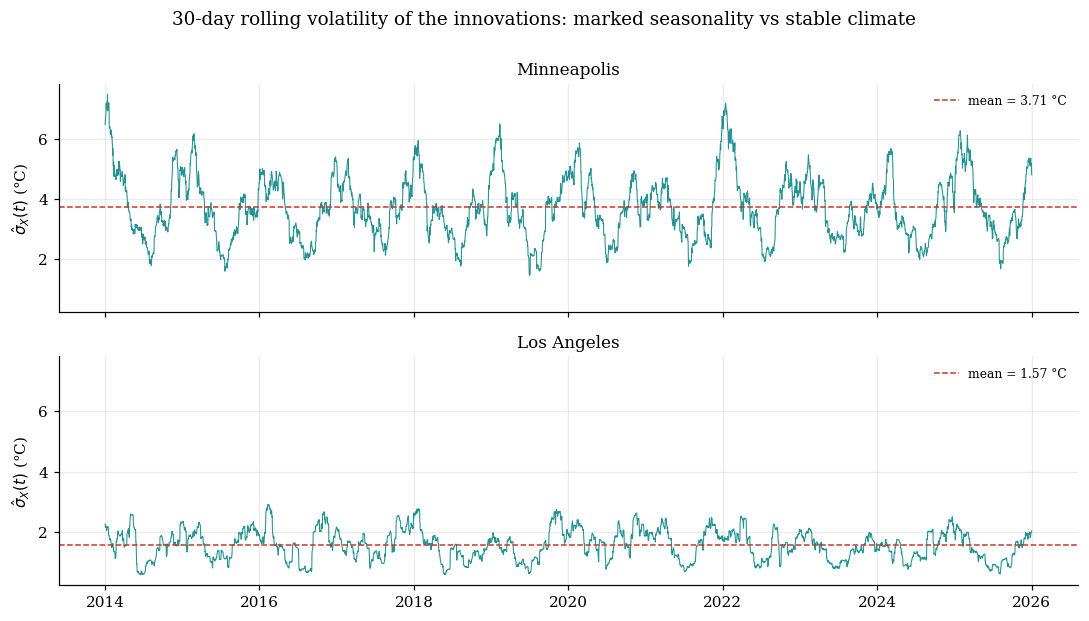

In [2]:
# Diagnostic rolling vol sigma_X_t, two contrasting climates suffice here
fig, axes = plt.subplots(2, 1, figsize=(10, 5.6), sharex=True, sharey=True)
for ax, city in zip(axes, ["minneapolis", "los_angeles"]):
    d = dfs[city].iloc[-365*12:]
    ax.plot(d.index, d["sigma_X_t"], color="teal", lw=0.7, alpha=0.85)
    ax.axhline(d["sigma_X_t"].mean(), color="#c0392b", ls="--", lw=1,
               label=f"mean = {d['sigma_X_t'].mean():.2f} °C")
    ax.set_title(city.replace("_", " ").title()); ax.set_ylabel("$\\hat\\sigma_X(t)$ (°C)")
    ax.legend(frameon=False, fontsize=8)
fig.suptitle("30-day rolling volatility of the innovations: marked seasonality vs stable climate", y=1.0)
fig.tight_layout()

The volatility $\hat{\sigma}_X(t)$ shows a marked seasonality: winters are systematically
more volatile than summers, reflecting greater temperature variability in cold periods. This has
a direct risk-management implication: uncertainty on HDDs (weather-derivative payoffs, among
others) is structurally higher in winter.

We assume $\sigma_X(t)$ satisfies:

$$\sigma_X(t) = \sigma_X(t + 365)$$

This assumption is empirically supported by the stationarity of $\hat{\sigma}_X(t)$ observed over the estimation window, with no trend or regime change.

We therefore estimate $\sigma_X$ over one annual cycle. For each day $j \in \{1, \ldots, 365\}$, we pool all innovations whose rank in the year is $j$:

$$\hat{\sigma}_X(j) = \sqrt{\frac{2\kappa}{1 - e^{-2\kappa}}} \cdot \sqrt{\frac{1}{|\mathcal{T}_j|} \sum_{t \in \mathcal{T}_j} \hat{\varepsilon}_t^2}$$

where $\mathcal{T}_j = \{t : t \equiv j \pmod{365}\}$ is the set of days matching the $j$-th
day of the year across the whole sample.

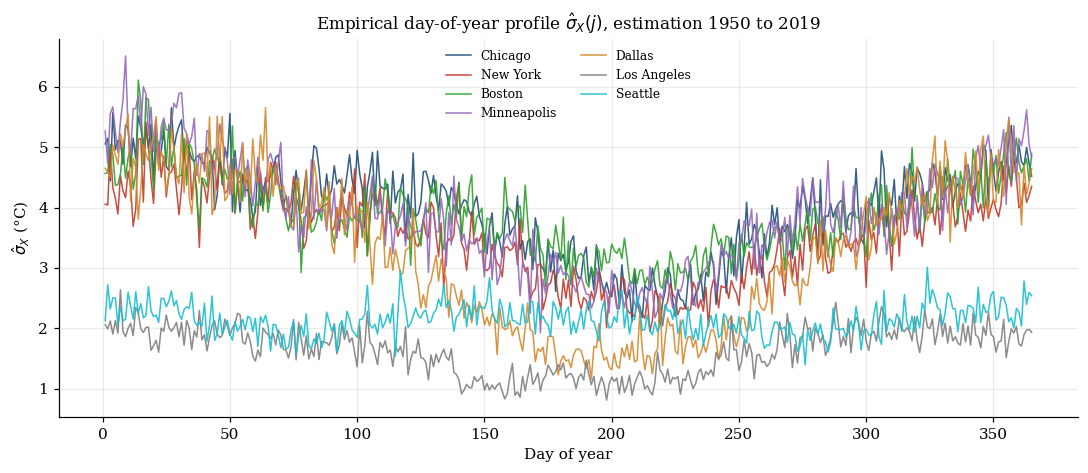

In [3]:
# Empirical profile sigma_X(doy), all 7 cities: the geographic hierarchy of
# winter volatility is the point (continental >> oceanic).
fig, ax = plt.subplots(figsize=(10, 4.4))
for c in ALL_CITIES:
    ax.plot(doy, params[c]["sigma_emp_doy"], lw=1.0, color=CITY_COLORS[c],
            label=c.replace("_", " ").title(), alpha=0.9)
ax.set_xlabel("Day of year"); ax.set_ylabel("$\\hat\\sigma_X$ (°C)")
ax.set_title("Empirical day-of-year profile $\\hat\\sigma_X(j)$, estimation 1950 to 2019")
ax.legend(frameon=False, fontsize=8, ncols=2)
fig.tight_layout()

## 2.2 Volatility Models

### 2.2.1 Piecewise Constant Volatility Model

As a first approximation, $\sigma_X(t)$ can be assumed constant within each month of
the year:
$$\sigma_X(t) = \begin{cases}
\sigma_1, & \text{January}, \\
\sigma_2, & \text{February}, \\
\vdots & \vdots \\
\sigma_{12}, & \text{December},
\end{cases}$$

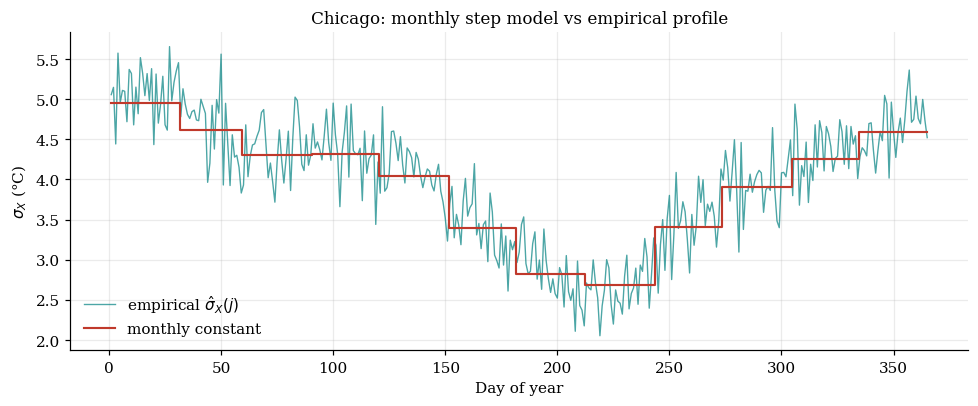

In [4]:
FOCUS = "chicago"
d_est = dfs[FOCUS].loc[:TRAIN_END]
sigma_monthly = d_est.groupby(d_est.index.month)["sigma_X_t"].mean()
emp = params[FOCUS]["sigma_emp_doy"]

# doy to month (non-leap reference year)
ref = pd.date_range("2001-01-01", "2001-12-31", freq="D")
step = sigma_monthly.reindex(ref.month).to_numpy()

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(doy, emp, color="teal", lw=0.9, alpha=0.7, label="empirical $\\hat\\sigma_X(j)$")
ax.step(doy, step, where="mid", color="#c0392b", lw=1.4, label="monthly constant")
ax.set_xlabel("Day of year"); ax.set_ylabel("$\\sigma_X$ (°C)")
ax.set_title(f"{FOCUS.title()}: monthly step model vs empirical profile")
ax.legend(frameon=False)
fig.tight_layout()

The model tracks the broad pattern reasonably well but hits a major limitation: it is
not differentiable at month boundaries. Let us model the volatility differently.

### $\sigma_X(t)$ Fourier Series

The volatility behaves like a sum of harmonics, in the manner of a Fourier series:

$$\sigma_X(t) = \sigma_0 + \sum_{k=1}^{K} \left( a_k \cos\left(\frac{2\pi k t}{365.25}\right) + b_k \sin\left(\frac{2\pi k t}{365.25}\right) \right)$$

The goal is to determine the optimal order $K$, reusing the same approach as for
$\theta(t)$.

In [ ]:
# Orders K selected by BIC
pd.DataFrame([{"city": c, "order K (BIC)": params[c]["sigma_fourier_order"]}
              for c in ALL_CITIES]).set_index("city").T

city,chicago,new_york,boston,minneapolis,dallas,los_angeles,seattle
order K (BIC),4,3,3,4,2,5,4


### $\sigma_X(t)$ B-Splines

A structural problem appears at the boundaries: a B-spline fitted on $j \in [1, 365]$
does not respect the annual periodicity constraint. By assumption, $\sigma_X(t)$ is periodic
with period 365:

$$\sigma_X(1) = \sigma_X(365) \quad \text{and} \quad \sigma_X'(1) = \sigma_X'(365)$$

A spline fitted on a bounded interval does not satisfy these boundary constraints. To fix it,
we periodize the signal by tripling the data over three consecutive cycles:

$$j_{\text{ext}} = [-364, \ldots, 0, 1, \ldots, 365, 366, \ldots, 730]$$

$$\sigma_{\text{ext}}(j) = \sigma_X(j \bmod 365)$$

We fit the cubic B-spline on this extended signal, then keep only the central cycle
$j \in [1, 365]$. The spline sees enough context on both sides of the boundaries to implicitly
respect continuity and differentiability at $j=1$ and $j=365$.

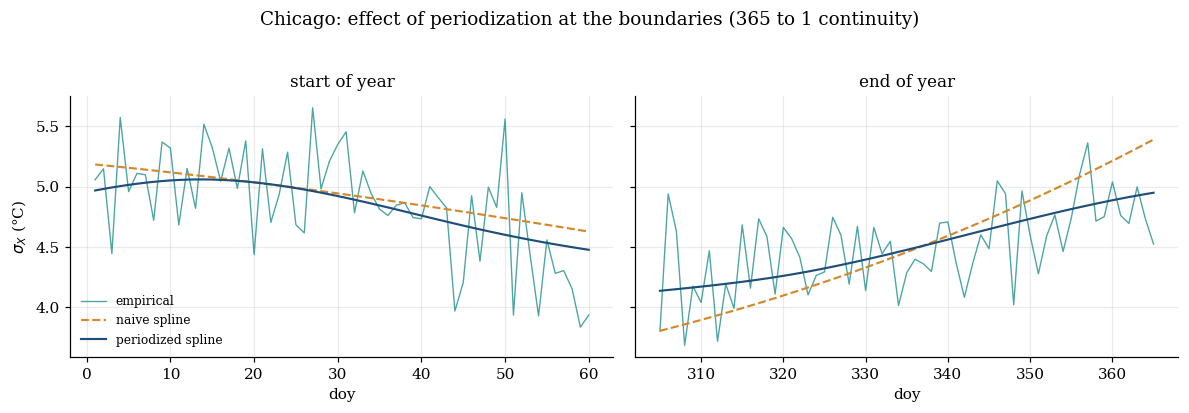

In [6]:
# Boundary problem illustrated: naive spline on [1,365] vs PERIODIZED spline (pipeline)
emp = params[FOCUS]["sigma_emp_doy"]
s_naive = UnivariateSpline(doy.astype(float), emp, s=len(emp)*np.var(emp)*0.5, k=3)(doy.astype(float))
s_per   = params[FOCUS]["sigma_spline_doy"]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, lo, hi, t in [(axes[0], 1, 60, "start of year"), (axes[1], 305, 365, "end of year")]:
    m = (doy >= lo) & (doy <= hi)
    ax.plot(doy[m], emp[m], color="teal", lw=0.9, alpha=0.7, label="empirical")
    ax.plot(doy[m], s_naive[m], color="#d4882b", lw=1.4, ls="--", label="naive spline")
    ax.plot(doy[m], s_per[m], color="#1f4e79", lw=1.4, label="periodized spline")
    ax.set_title(t); ax.set_xlabel("doy")
axes[0].set_ylabel("$\\sigma_X$ (°C)"); axes[0].legend(frameon=False, fontsize=8)
fig.suptitle(f"{FOCUS.title()}: effect of periodization at the boundaries (365 to 1 continuity)", y=1.03)
fig.tight_layout()

### Model Comparison

We overlay the three candidate models on the focus city, then compare their fit to the empirical profile by RMSE across the 7 cities.

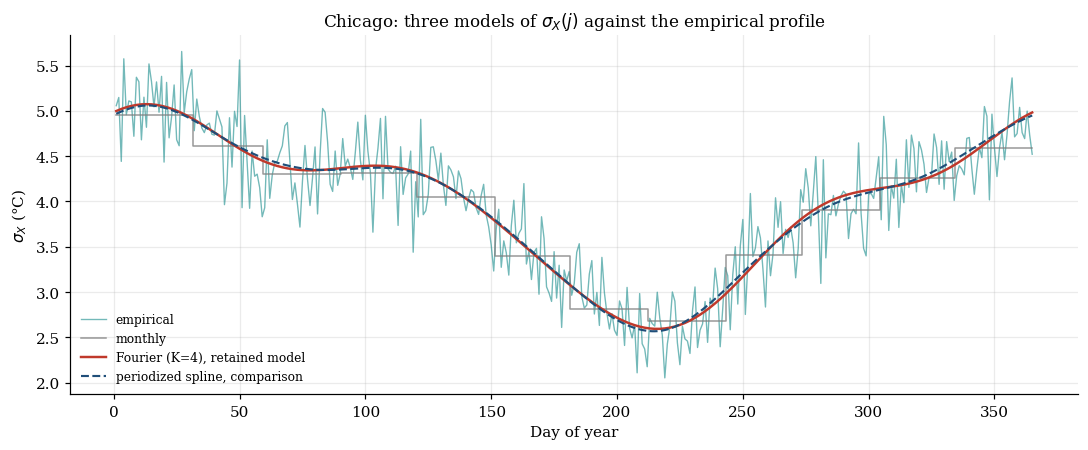

In [7]:
# The three models, focus city, then RMSE across the 7 cities
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(doy, params[FOCUS]["sigma_emp_doy"], color="teal", lw=0.9, alpha=0.55, label="empirical")
ax.step(doy, step, where="mid", color="#7f7f7f", lw=1.0, alpha=0.8, label="monthly")
ax.plot(doy, params[FOCUS]["sigma_fourier_doy"], color="#c0392b", lw=1.6,
        label=f"Fourier (K={params[FOCUS]['sigma_fourier_order']}), retained model")
ax.plot(doy, params[FOCUS]["sigma_spline_doy"], color="#1f4e79", lw=1.4, ls="--",
        label="periodized spline, comparison")
ax.set_xlabel("Day of year"); ax.set_ylabel("$\\sigma_X$ (°C)")
ax.set_title(f"{FOCUS.title()}: three models of $\\sigma_X(j)$ against the empirical profile")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()

In [8]:
# RMSE of each model against the empirical profile, all 7 cities
rows = []
for c in ALL_CITIES:
    emp_c = np.asarray(params[c]["sigma_emp_doy"])
    d_e = dfs[c].loc[:TRAIN_END]
    step_c = d_e.groupby(d_e.index.month)["sigma_X_t"].mean().reindex(ref.month).to_numpy()
    rows.append({
        "city": c,
        "RMSE monthly": np.sqrt(np.nanmean((emp_c - step_c) ** 2)),
        "RMSE Fourier": np.sqrt(np.mean((emp_c - np.asarray(params[c]['sigma_fourier_doy'])) ** 2)),
        "RMSE spline":  np.sqrt(np.mean((emp_c - np.asarray(params[c]['sigma_spline_doy'])) ** 2)),
        "max |Fourier - spline|": np.max(np.abs(np.asarray(params[c]['sigma_fourier_doy'])
                                                - np.asarray(params[c]['sigma_spline_doy']))),
    })
pd.DataFrame(rows).set_index("city").round(4)

,RMSE monthly,RMSE Fourier,RMSE spline,max |Fourier - spline|
city,,,,
chicago,0.3466,0.3172,0.3174,0.0556
new_york,0.3289,0.3084,0.2899,0.2448
boston,0.3449,0.3244,0.3072,0.3357
minneapolis,0.3654,0.3270,0.3226,0.1634
dallas,0.4123,0.3504,0.3391,0.2015
los_angeles,0.2037,0.1927,0.1818,0.1899
seattle,0.2146,0.2047,0.2039,0.0322


## Conclusion

Three approaches were compared to model $\sigma_X(t)$: a monthly step function, a Fourier
series and a periodized cubic B-spline.

The monthly function is too coarse. Discontinuities at month boundaries introduce artifacts
in the Monte Carlo simulation and violate the physical continuity of volatility.

The Fourier series and the periodized cubic B-spline produce empirically indistinguishable
results on every station (see the RMSE table above). The choice therefore rests on consistency
criteria: the **Fourier series is retained as the model**, with the same order-selection machinery as
$\theta(t)$ (methodological coherence), compact parametrization in the artifacts, and exact
periodicity by construction. The periodized spline is kept as a comparison column
(`sigma_X_spline`), and remains available in the simulator via `sigma_profile="spline"`.

One important caveat: over the test period, the observed winter volatility, notably in
Minneapolis, sits systematically above the estimation profile. This drift reflects a climatic
non-stationarity that a deterministic seasonal model cannot capture by construction. It is
addressed in the scenario / stress-testing engine (workstream 3b).